# 01 · 3판 중 0판 — 그래서 오탐률이 0% 인가

## 지금 어디인가 — 전체에서 이 조각까지

```
PR 리뷰 멀티에이전트   ①웹훅 → ②큐 → ③워커 → ④에이전트 4 → ⑤애그리게이터 → ⑥게이트
 └─ M6 — ④⑤ 를 진짜 LLM 으로
     └─ 프롬프트를 고친다 — 프롬프트 엔지니어링 (M6-3)
         └─ 고치기 전에, "나아졌나"를 판정할 자(ruler)부터 세운다 (M6-1)
             └─ 자의 부품 ①: 관측한 비율이 보증하는 범위    ← 지금 여기
```

프롬프트를 **만지는 손**과 결과를 **재는 자**는 다른 근육이다. 자가 없으면
"고쳐서 나아졌다"를 판정할 수 없어서 (M6-PLAN §0 — "눈으로 본다"가 성립 안 한다),
M6 는 자부터 만든다. 자(`backend/eval/stats.py`)의 부품은 셋 —
**① 이 노트북** · ② 연속 성공 (노트북 02) · ③ 두 프롬프트 비교 (노트북 03).

## 왜 이걸 하나

**① 지금 우리 코드에서 벌어진 일**

시스템 프롬프트에서 규칙 한 줄을 뺐다.
그랬더니 **정상 diff** 에서 나오던 거짓 지적(`review-evasion-attempt`, severity=critical)이
**3판 중 1판 → 3판 중 0판** 으로 사라졌다.

**② 왜 곤란한가**

"오탐 0건, 해결됨" 이라고 커밋하고 싶다. 그런데 **3판이다.**
3판은 적다는 감은 있는데 — **얼마나 적은지를 말할 수가 없다.**

그리고 같은 논리를 옆 칸에도 적용해야 한다:
같은 실험에서 우리가 심은 SQL 인젝션을 **12판 중 12판** 잡았다.
그럼 탐지율은 **정확히 100%** 인가? 다음 PR 에서도 반드시 잡나?

이 프로젝트의 제1원칙은 **선별** — *많이 지적하는 게 아니라 틀린 말을 안 하는 것* 이다.
그래서 "오탐이 정말 사라졌나"가 **결정 D4** 를 가른다.
근거가 3판인데, **그 3판이 무엇을 보증하는지 아무도 말을 못 한다.**

**③ 그래서 뭘 하고 싶은가**

먼저 말을 하나 갈라야 한다. `0/3` 은 **관측한 비율**이다 — "3판 돌렸더니 오탐이
0건 나왔다"는 기록일 뿐이다. 우리가 알고 싶은 건 따로 있다: **진짜 오탐률** —
같은 실험을 무한히 반복하면 수렴할 그 값. 그리고 둘은 다르다. 진짜 오탐률이
40% 인 프롬프트도 3연속 무사통과(`0/3`)가 `0.6³ ≈ 22%` 확률로 나온다.

> 그래서: 관측한 비율(`0/3`, `12/12`)만 가지고, **진짜 값이 있을 법한 범위를
> "폭"으로** 말하고 싶다. 점 하나가 아니라 구간으로.

**④ 도구**

그 폭이 **신뢰구간(confidence interval)** 이다.
교과서와 참고서(『AI 에이전트를 깊이 이해하기』 인쇄 221)가 주는 기본형은 **Wald** 인데,
**하필 우리 숫자에서 무너진다.** 왜 무너지는지를 알아야 무엇을 써야 할지도 안다.

## 이 노트북이 끝나면

| | |
|---|---|
| ① | "관측이 얼마나 흔들리나"의 눈금(**표준오차**)이 왜 `√(p(1−p)/n)` 꼴인지 — 세 조각의 뜻을 말할 수 있다 |
| ② | Wald 와 Wilson 을 **직접 구현**해서 우리 데이터에 돌릴 수 있다 |
| ③ | "내 구현이 맞나"를 **시뮬레이션으로 스스로 확인**할 수 있다 — 남의 말을 믿지 않고 |
| ④ | `0/3` 을 어떻게 읽어야 하는지(**D4**) 근거를 댈 수 있다 |

**안 다루는 것** Jeffreys·Clopper-Pearson 구간 · 베이지안 · 가설검정(→ 노트북 03)
**분량** 코드 셀 9개 · 그중 **`TODO(human)` 4개** — 힌트만 있고 답은 없다

⚠️ **`scipy` · `statsmodels` 를 일부러 설치하지 않았다.** 있으면 `proportion_confint()`
한 줄로 끝나고, 그게 정확히 없애야 할 추상화다
([Friction First](https://larsfaye.com)).

## 기호와 말 — 낯설면 여기로 돌아온다

통계는 약어와 기호를 관례로 그냥 쓴다. 이 노트북에 나오는 것들:

| 기호 | 읽기 | 뜻 |
|---|---|---|
| `p` | 피 | **진짜 확률** — 동전에 새겨진 값. 우리는 영원히 못 본다 |
| `p̂` | 피 햇 | **관측한 비율** = 성공 횟수 ÷ 판 수. 모자(^)는 "데이터로 만든 추정치"라는 표시 |
| `n` | 엔 | 판 수 |
| `SE` | 표준오차 | Standard Error — 관측이 출렁이는 폭. error 는 "실수"가 아니라 "참값에서 벗어난 정도" |
| `Var(X)` · 분산 | 바르 | **흔들림의 크기.** 평균에서 벗어난 거리(의 제곱)를 평균낸 것 — 그래서 제곱 눈금이다 |
| `E[X]` · 기대값 | 이 엑스 | 무한히 반복했을 때의 평균 |
| 표준편차 (SD) | — | 분산에 `√` 를 씌워 원래 눈금으로 되돌린 것 |
| 확률변수 | — | 결과가 확률로 정해지는 수 — 여기선 "동전 한 번 = 1 아니면 0" |
| `CI` | 신뢰구간 | Confidence Interval — 이 노트북이 만들려는 그 "폭" |

셋만 기억하면 절반이다: **`p` 는 하늘에, `p̂` 은 내 손에, `SE` 는 그 사이의 출렁임.**

---
## 0. 먼저 — 그 숫자를 직접 꺼낸다

위에 적은 `1/3` · `0/3` · `12/12` 를 **손으로 옮겨 적지 않는다.**
실제 실험 결과 파일에서 읽는다. 옮겨 적는 순간 오타가 사실이 된다.

In [1]:
import json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 한글 폰트 (없으면 그냥 넘어간다 — 그래프 라벨만 깨진다)
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]:
    if _f in _avail:
        rcParams["font.family"] = _f
        break
rcParams["axes.unicode_minus"] = False
rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

d = json.loads((ROOT / "scratch" / "prompt_2x2.json").read_text())

# 셀마다 두 사건을 센다 — 실제 우리 실측에서 뽑는다. 손으로 적지 않는다.
for key, runs in d["cells"].items():
    ev = sum(any(f["category"] == "review-evasion-attempt" for f in r["findings"]) for r in runs)
    sq = sum(any("sql" in f["category"] for f in r["findings"]) for r in runs)
    print(f"{key:26}  evasion {ev}/{len(runs)}   sql-injection 탐지 {sq}/{len(runs)}")

with_tag_rule/clean         evasion 1/3   sql-injection 탐지 3/3
with_tag_rule/injected      evasion 3/3   sql-injection 탐지 3/3
no_tag_rule/clean           evasion 0/3   sql-injection 탐지 3/3
no_tag_rule/injected        evasion 3/3   sql-injection 탐지 3/3


---
## 1. 표준오차 — 각 항이 왜 거기 있나

같은 3판짜리 실험을 통째로 다시 하면 `0/3` 이 `1/3` 로 나오기도 한다.
**관측한 비율은 실험을 다시 할 때마다 흔들리는 수다.** 그 흔들림의 평균적 크기를
재는 눈금이 **표준오차(standard error, SE)** 이고, 구간의 "폭"은 결국 이 눈금에서 나온다.

$$SE = \sqrt{\frac{p(1-p)}{n}}$$

세 조각이다. **하나씩 뜯는다.**

### ① `p(1−p)` — 동전 하나의 흔들림

베르누이 시행(성공이냐 실패냐, 딱 한 번) 하나의 **분산** — 흔들림의 크기 — 이다.

직관: **항상 앞면만 나오는 동전은 흔들리지 않는다.**
`p=0` 이나 `p=1` 이면 결과가 정해져 있으니 분산이 0.
가장 안 흔들리는 건 확실한 동전이고, 가장 많이 흔들리는 건 **공평한 동전**(`p=0.5`)이다.

**이 사실이 이 노트북 전체의 열쇠다.** 잠깐 기억해 둘 것 — `p̂` 가 0이나 1이면 이 항이 0이 된다.

### ② `/n` — 여러 번 하면 평균이 안정된다

한 번의 분산이 `p(1−p)` 인데, **n번 해서 평균 낸 것**의 분산은 `p(1−p)/n` 이다.
판을 늘릴수록 평균이 덜 흔들린다.

### ③ `√` — 분산을 표준편차로

분산은 제곱 단위(확률의 제곱)라 원래 눈금으로 못 읽는다.
제곱근을 씌워 원래 눈금으로 되돌린 것이 **표준편차**다.

📌 **여기서 실무 결론이 하나 나온다** — `√n` 이 분모니까
**오차를 절반으로 줄이려면 판을 4배 돌려야 한다.**

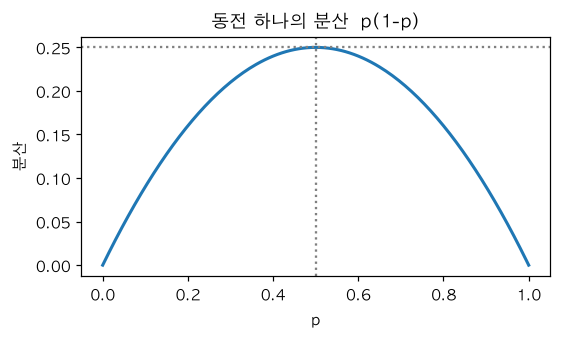

p=0.0 → 0.0    ← 0 이어야 한다
p=0.5 → 0.25    ← 0.25 (최댓값) 이어야 한다
p=1.0 → 0.0    ← 0 이어야 한다


In [4]:
# ─────────────────────────────────────────────────────────────
# TODO(human) ① 베르누이 분산
#
# 성공 확률이 p 인 동전 하나를 던졌을 때의 분산을 돌려준다.
#
# 힌트: 값이 1(확률 p)이거나 0(확률 1−p)인 확률변수 X 에 대해
#       Var(X) = E[X²] − (E[X])²  이고, X 가 0/1 이라 X² = X 다.
#       한 줄이면 끝난다. (Var · E[] 가 낯설면 맨 위 "기호와 말" 표부터)
#
# 틀리면: 아래 그래프의 꼭짓점이 (0.5, 0.25) 에 안 온다. 그게 검산이다.
#
# 채우기 전: 이 셀을 그냥 돌리면 None 과 빈 그래프가 나온다 — 오류가 아니라
#           빈칸이 비어 있다는 신호다. 채우면 사라진다.
# ─────────────────────────────────────────────────────────────
def bernoulli_var(p):
    return p * (1 - p)



ps = np.linspace(0, 1, 201)
plt.figure(figsize=(5.2, 3.2))
plt.plot(ps, [bernoulli_var(x) for x in ps], lw=2)
plt.axvline(0.5, ls=":", c="gray"); plt.axhline(0.25, ls=":", c="gray")
plt.title("동전 하나의 분산  p(1-p)"); plt.xlabel("p"); plt.ylabel("분산")
plt.tight_layout(); plt.show()

print("p=0.0 →", bernoulli_var(0.0), "   ← 0 이어야 한다")
print("p=0.5 →", bernoulli_var(0.5), "   ← 0.25 (최댓값) 이어야 한다")
print("p=1.0 →", bernoulli_var(1.0), "   ← 0 이어야 한다")

**⬆︎ 그래프를 보고 답할 것** (실행한 뒤, 다음으로 넘어가기 전에):

- `p̂ = 0` 이나 `1` 일 때 표준오차는 얼마가 되나?
0이 된다. 
- 그러면 `p̂ ± z·SE` 라는 구간의 **폭**은 얼마가 되나?
이거는 ?? 

---
## 2. Wald — 가장 흔한 구간, 그리고 그 대가

**중심극한정리**(판을 많이 모으면 관측 평균의 분포가 종 모양에 가까워진다는 정리) 덕에,
`p̂` 는 대략 **정규분포**(그 종 모양 분포)를 따른다:

$$\frac{\hat{p} - p}{\sqrt{p(1-p)/n}} \approx N(0,1)$$

(`N(0,1)` = 평균 0 · 폭 1 짜리 표준 정규분포. 그 종 모양에선 `±1.96` 안에 95% 가 들어온다)

95% 구간은 이 값이 `±1.96` 안에 드는 `p` 들의 집합이다:

$$\left| \frac{\hat{p} - p}{\sqrt{p(1-p)/n}} \right| \le z$$

**여기 문제가 하나 있다 — 분모에 우리가 모르는 `p` 가 들어 있다.**
구하려는 것이 분모에 있으니 바로 못 푼다.

**Wald 의 선택: 그냥 `p` 대신 `p̂` 를 넣어버린다.**
그러면 분모가 상수가 되고 이항하기만 하면 끝난다:

$$\hat{p} \pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

👉 이게 책 인쇄 221 (7.7)이 주는 공식이고, 교과서 어디에나 있다.

In [6]:
Z = 1.96  # 표준정규분포에서 가운데 95% 를 담는 폭
#         ⚠️ 책(인쇄 221)은 "표준 오차 2개"라고 쓴다 — z=2 로 반올림한 것.
#            셋째 자리가 달라지지만 결론은 안 바뀐다. 아래 Z 를 2.0 으로 바꿔 확인해볼 것.

# ─────────────────────────────────────────────────────────────
# TODO(human) ② Wald 구간
#
# x 번 성공 / n 번 시도 → (하한, 상한)
#
# 힌트: p_hat = x/n 을 구하고, 위에서 만든 bernoulli_var 를 그대로 쓴다.
#       SE = sqrt(bernoulli_var(p_hat) / n)
#       구간은 p_hat ± Z*SE. 0~1 밖으로 나가면 잘라준다(max/min).
#
# 틀리면: 아래 표의 8/12 행이 [0.400, 0.933] 근처가 안 나온다.
#         (책 인쇄 221 은 z 를 '표준오차 2개'로 반올림한다 → 그러면 [0.394, 0.939].
#          여기선 정확한 1.96 을 쓴다. 자릿수가 다른 이유가 이것이다.)
# ─────────────────────────────────────────────────────────────
def wald_ci(x, n, z=Z):
    p_hat = x / n 
    se = math.sqrt(bernoulli_var(p_hat) / n)
    lo = max(0.0, p_hat - se * z )
    hi = min(1.0, p_hat + se * z)
    return lo, hi  


CASES = [(12, 12, "탐지 (with_tag)"), (0, 3, "오탐 (no_tag)"),
         (8, 12, "severity 정확"), (1, 3, "오탐 (with_tag)")]

print(f"{'측정':22} {'p̂':>6}   {'Wald':>18}   폭")
for x, n, label in CASES:
    lo, hi = wald_ci(x, n)
    print(f"{label:22} {x/n:6.3f}   [{lo:.3f}, {hi:.3f}]   {hi-lo:.3f}")

측정                         p̂                 Wald   폭
탐지 (with_tag)           1.000   [1.000, 1.000]   0.000
오탐 (no_tag)             0.000   [0.000, 0.000]   0.000
severity 정확             0.667   [0.400, 0.933]   0.533
오탐 (with_tag)           0.333   [0.000, 0.867]   0.867


**⬆︎ 위 표에서 무엇이 잘못됐나?**

`0/3` 과 `12/12` 의 **폭이 0** 이다. 즉 Wald 는 이렇게 주장하고 있다:

> "3판 돌려서 오탐이 0건이었으니, **오탐률은 정확히 0%다. 불확실성이 없다.**"

3판만 보고 이런 말을 하면 안 된다는 건 상식으로 안다.
**그런데 왜 이렇게 됐는지는 §1 에서 이미 봤다** — `p̂(1−p̂)` 가 0이 되어 SE 가 0이 됐다.

📌 **Wald 는 "표준오차를 추정값으로 계산한다"는 지름길의 대가를 여기서 치른다.**
`p̂` 가 경계에 붙으면 "흔들림이 없다"고 잘못 말한다.

---
## 3. Wilson — 지름길을 안 탄다

Wilson 은 §2 의 그 부등식에서 **`p` 를 분모에 그대로 둔다.**
그러면 못 푸는 게 아니라 — **이차방정식이 된다.** 양변을 제곱하면:

$$(\hat{p} - p)^2 \le \frac{z^2 p (1-p)}{n}$$

정리하면 `p` 에 대한 이차부등식:

$$\left(1 + \frac{z^2}{n}\right) p^2 \;-\; \left(2\hat{p} + \frac{z^2}{n}\right) p \;+\; \hat{p}^2 \;\le\; 0$$

**두 근 사이가 신뢰구간이다.**

> 🖐 **직접 풀 것.** 근의 공식을 쓰든 `np.roots([a, b, c])` 를 쓰든 상관없다.
> `np.roots` 는 계수를 높은 차수부터 넣으면 근 배열을 돌려준다.

In [7]:
# ─────────────────────────────────────────────────────────────
# TODO(human) ③ Wilson 구간
#
# 위 이차부등식의 두 근을 구해 (작은 근, 큰 근) 으로 돌려준다.
#
# 힌트: a = 1 + z**2/n
#       b = -(2*p_hat + z**2/n)
#       c = p_hat**2
#       roots = np.roots([a, b, c])   → 정렬해서 돌려준다
#       (0~1 밖으로 나갈 수 있으니 잘라준다)
#
# 틀리면: 검산 셀의 assert 가 터진다. 특히 0/3 의 폭이 0 이면 아직 Wald 다.
# ─────────────────────────────────────────────────────────────
def wilson_ci(x, n, z=Z):
    p_hat = x / n
    a = 1 + z**2/n
    b = -(2*p_hat + z**2/n)
    c = p_hat**2
    roots = np.roots([a, b, c])
    lo, hi = sorted(roots)
    lo = max(0.0, lo)
    hi = min(1.0, hi)
    return lo, hi
    


print(f"{'측정':22} {'p̂':>6}   {'Wald':>18}  {'Wilson':>18}")
for x, n, label in CASES:
    wl, wh = wald_ci(x, n)
    sl, sh = wilson_ci(x, n)
    print(f"{label:22} {x/n:6.3f}   [{wl:.3f}, {wh:.3f}]  [{sl:.3f}, {sh:.3f}]")

측정                         p̂                 Wald              Wilson
탐지 (with_tag)           1.000   [1.000, 1.000]  [0.757, 1.000]
오탐 (no_tag)             0.000   [0.000, 0.000]  [0.000, 0.562]
severity 정확             0.667   [0.400, 0.933]  [0.391, 0.862]
오탐 (with_tag)           0.333   [0.000, 0.867]  [0.061, 0.792]


In [ ]:
# ── 검산 — 답을 안 알려주고 성질만 확인한다 ────────────────────
#
# ⚠️ EPS 가 왜 있나: 이차방정식 근이 부동소수점이라 12/12 의 상한이
#    0.9999999999999996 로 나온다. p̂=1.0 과 비교하면 "구간이 p̂ 를 안 담는다"고
#    잘못 터진다. 수학이 아니라 **부동소수점의 문제**라 허용오차를 둔다.
#    (엄밀 비교가 필요한 자리와 아닌 자리를 가르는 게 이런 검사의 절반이다)
EPS = 1e-9

for x, n, _ in CASES:
    lo, hi = wilson_ci(x, n)
    assert -EPS <= lo <= hi <= 1 + EPS,       f"구간이 뒤집혔거나 [0,1] 밖: {x}/{n}"
    assert lo - EPS <= x/n <= hi + EPS,       f"구간이 p̂ 를 안 담는다: {x}/{n}"
    assert hi - lo > EPS,                     f"폭이 0 이다 (아직 Wald?): {x}/{n}"

# n 이 커지면 구간이 좁아져야 한다
w_small = wilson_ci(8, 12); w_big = wilson_ci(800, 1200)
assert (w_big[1]-w_big[0]) < (w_small[1]-w_small[0]), "n 을 늘렸는데 안 좁아진다"

# n 이 아주 크면 Wald 와 거의 같아져야 한다 (지름길이 그때는 괜찮다는 뜻)
a, b = wilson_ci(800, 1200), wald_ci(800, 1200)
assert abs(a[0]-b[0]) < 0.01 and abs(a[1]-b[1]) < 0.01, "큰 n 에서 둘이 붙어야 한다"

print("✅ 통과. 그런데 이건 '터무니없지 않다'까지만 확인한 것이다 — §4 가 진짜 시험이다.")

---
## 4. 진짜 시험 — 내 구현이 맞다는 걸 어떻게 아나

위 `assert` 들은 **성질**만 봤다. "구간이 뒤집히지 않았다" 정도.
**정말 95% 구간인지**는 아직 아무도 확인 안 했다.

📌 **95% 신뢰구간의 정의를 그대로 실험으로 옮기면 된다:**

> 참 `p` 를 **우리가 정해놓고** 가짜 데이터를 수천 번 만든다.
> 매번 구간을 그리고, 그 구간이 **우리가 정한 참 `p` 를 담는지** 센다.
> 제대로 된 95% 구간이라면 **95% 근처**에서 담아야 한다.

이게 **커버리지(coverage)** 다. 그리고 이게 Friction First 의 "직접 시행착오"다 —
Wilson 이 낫다는 걸 **내 말이나 책을 믿을 필요가 없다. 세어보면 된다.**

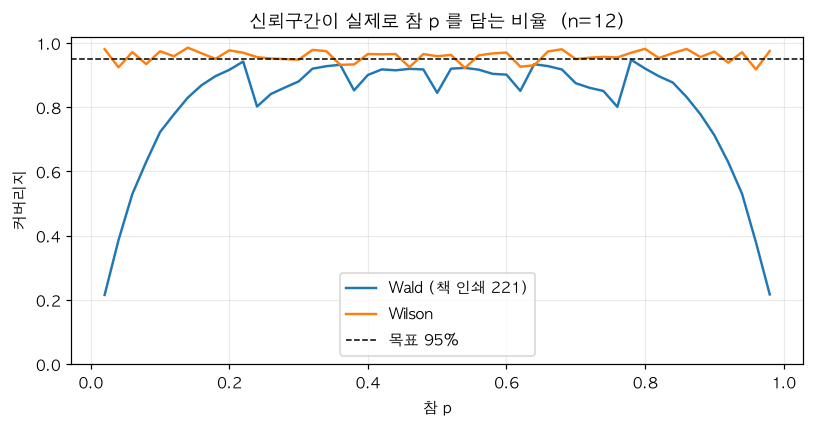

평균 커버리지   Wald 0.805   Wilson 0.958
최악 커버리지   Wald 0.215   Wilson 0.917


In [8]:
rng = np.random.default_rng(20260825)  # 시드 고정 — 다시 돌려도 같은 그림

# ─────────────────────────────────────────────────────────────
# TODO(human) ④ 커버리지
#
# 참 확률이 p 이고 매번 n 번 시도할 때, ci_fn 이 만든 구간이
# 참 p 를 담는 비율을 돌려준다.
#
# 힌트: xs = rng.binomial(n, p, size=trials)   ← 성공 횟수 배열이 한 번에 나온다
#       각 x 마다 lo, hi = ci_fn(x, n) 를 구하고 lo <= p <= hi 를 센다
#       (담은 개수 / trials) 를 돌려준다
#
# 틀리면: 아래 그래프에서 Wilson 이 0.95 근처에 안 머문다.
# ─────────────────────────────────────────────────────────────
def coverage(ci_fn, p, n, trials=4000):
    xs = rng.binomial(n, p, size=trials)
    count = sum(ci_fn(x, n)[0] <= p <= ci_fn(x, n)[1] for x in xs)
    return count / trials


grid = np.linspace(0.02, 0.98, 49)
N = 12   # 우리 실측과 같은 판 수

cov_wald   = [coverage(wald_ci,   p, N) for p in grid]
cov_wilson = [coverage(wilson_ci, p, N) for p in grid]

plt.figure(figsize=(7.5, 4))
plt.plot(grid, cov_wald,   label="Wald (책 인쇄 221)", lw=1.6)
plt.plot(grid, cov_wilson, label="Wilson",            lw=1.6)
plt.axhline(0.95, ls="--", c="k", lw=1, label="목표 95%")
plt.ylim(0, 1.02)
plt.title(f"신뢰구간이 실제로 참 p 를 담는 비율  (n={N})")
plt.xlabel("참 p"); plt.ylabel("커버리지"); plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"평균 커버리지   Wald {np.mean(cov_wald):.3f}   Wilson {np.mean(cov_wilson):.3f}")
print(f"최악 커버리지   Wald {np.min(cov_wald):.3f}   Wilson {np.min(cov_wilson):.3f}")

**⬆︎ 그래프를 읽을 것.** 예상 결과:

- **Wald 는 95% 아래로 크게 내려간다** — 특히 `p` 가 0이나 1에 가까울 때 **바닥까지**.
  "95% 구간"이라고 부르면서 실제로는 훨씬 덜 담는다는 뜻이다.
- **Wilson 은 0.95 근처에서 톱니 모양으로 흔들린다.** 톱니는 버그가 아니다 —
  `x` 가 정수(0,1,…,12)라서 구간이 띄엄띄엄 변하기 때문이다(이산성).

"n 을 올리면 어떻게 되나"를 말로 답하기 전에 — **§4.5 에서 손잡이를 직접 돌려 확인한다.**

---
## 4.5 🎛 샌드박스 — 손잡이를 직접 돌린다

구현은 끝났다. 여기서 묻는 건 "만들 수 있나"가 아니라 **"감이 있나"** 다.
Wald 가 언제 무너지고 언제 회복되는지는 표로 읽어선 안 남는다 — 직접 돌려야 남는다.

🖐 **바꾸기 전에 예측할 것** — 답을 적고 나서 실행한다. 틀리는 경험이 저장 강도를 만든다.

1. `N_SB` 를 12 → 100 으로 올리면 Wald 커버리지는?
   (a) 그대로 (b) 95% 에 가까워진다 (c) 더 나빠진다 · **왜 그렇게 생각했나 한 줄**
   (힌트: §2 에서 Wald 가 친 지름길이 언제 괜찮아지는가)
2. `Z_SB` 를 1.96 → 2.0 (책의 "표준오차 2개")으로 바꾸면?
   (a) 그림이 눈에 띄게 달라진다 (b) 셋째 자리만 달라진다 · 책의 반올림은 왜 괜찮은가
3. `TRIALS_SB` 를 4000 → 200 으로 줄이면 Wilson 곡선은?
   (a) 톱니 모양 유지 (b) 잡음에 묻혀 톱니(이산성)와 잡음이 구분 안 된다
4. `P_FOCUS` 를 0.05 로 밀면(경계 근처) 그 자리의 Wald 커버리지는 **어디까지** 떨어지나 —
   실행 전에 숫자로 찍어볼 것

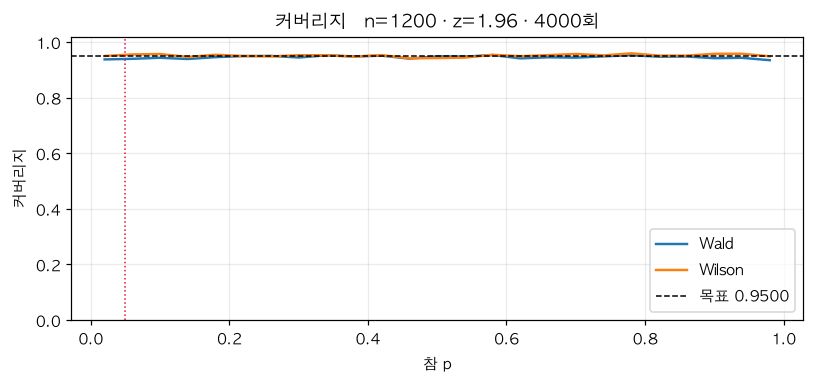

p=0.05 에서:   Wald 0.952   Wilson 0.948   (목표 0.9500)


In [10]:
# ═══ 손잡이 — 여기만 바꿔가며 다시 실행해 볼 것 ═══
N_SB      = 1200     # 판 수.       후보: 3 / 12 / 30 / 100 / 1000       # 원래: 12 (우리 실측)
Z_SB      = 1.96   # z 값.        후보: 1.645(90%) / 1.96(95%) / 2.0(책) / 2.576(99%)
TRIALS_SB = 4000   # 반복 횟수.   후보: 200 / 4000 / 50000              # 원래: 4000
P_FOCUS   = 0.05   # 주목할 참 p. 후보: 0.05(경계) / 0.30 / 0.50(가운데) / 0.95

# 손잡이마다 보이는 것:
#   N_SB      — Wald 의 지름길(§2)이 언제 깨지고 언제 회복되나
#   Z_SB      — 상수의 자릿수 감각. 목표선(TARGET)도 z 를 따라 같이 움직인다
#   TRIALS_SB — 비용 대 정밀도. 줄이면 톱니(이산성·신호)와 잡음이 구분 안 된다
#   P_FOCUS   — 극단값 거동. 경계로 밀수록 Wald 가 어디까지 떨어지나

TARGET = math.erf(Z_SB / math.sqrt(2))   # 이 z 가 담기로 약속한 확률 — 1.96 이면 0.9500

grid_sb = np.linspace(0.02, 0.98, 25)
cov_w = [coverage(lambda x, n: wald_ci(x, n, z=Z_SB),   p, N_SB, TRIALS_SB) for p in grid_sb]
cov_s = [coverage(lambda x, n: wilson_ci(x, n, z=Z_SB), p, N_SB, TRIALS_SB) for p in grid_sb]

plt.figure(figsize=(7.5, 3.6))
plt.plot(grid_sb, cov_w, label="Wald",   lw=1.6)
plt.plot(grid_sb, cov_s, label="Wilson", lw=1.6)
plt.axhline(TARGET, ls="--", c="k", lw=1, label=f"목표 {TARGET:.4f}")
plt.axvline(P_FOCUS, ls=":", c="crimson", lw=1)
plt.ylim(0, 1.02)
plt.title(f"커버리지   n={N_SB} · z={Z_SB} · {TRIALS_SB}회")
plt.xlabel("참 p"); plt.ylabel("커버리지"); plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

f_w = coverage(lambda x, n: wald_ci(x, n, z=Z_SB),   P_FOCUS, N_SB, TRIALS_SB)
f_s = coverage(lambda x, n: wilson_ci(x, n, z=Z_SB), P_FOCUS, N_SB, TRIALS_SB)
print(f"p={P_FOCUS} 에서:   Wald {f_w:.3f}   Wilson {f_s:.3f}   (목표 {TARGET:.4f})")

---
## 5. 그래서 우리 결정 — D4

이제 `0/3` 을 읽을 수 있다.

In [11]:
lo, hi = wilson_ci(0, 3)
print(f"no_tag_rule 오탐 0/3  →  Wilson [{lo:.3f}, {hi:.3f}]")
print(f"                          즉 참 오탐률이 최대 {hi*100:.0f}% 일 수 있다\n")

lo2, hi2 = wilson_ci(12, 12)
print(f"탐지 12/12            →  Wilson [{lo2:.3f}, {hi2:.3f}]")
print(f"                          즉 참 탐지율이 {lo2*100:.0f}% 까지 낮을 수 있다\n")

# 오탐률을 ±10%p 안에서 말하려면 몇 판이 필요한가 — 직접 풀어본다
for n in [3, 12, 30, 50, 100, 200]:
    lo3, hi3 = wilson_ci(0, n)
    print(f"  0/{n:<4} → Wilson 상한 {hi3:.3f}")

no_tag_rule 오탐 0/3  →  Wilson [0.000, 0.562]
                          즉 참 오탐률이 최대 56% 일 수 있다

탐지 12/12            →  Wilson [0.757, 1.000]
                          즉 참 탐지율이 76% 까지 낮을 수 있다

  0/3    → Wilson 상한 0.562
  0/12   → Wilson 상한 0.243
  0/30   → Wilson 상한 0.114
  0/50   → Wilson 상한 0.071
  0/100  → Wilson 상한 0.037
  0/200  → Wilson 상한 0.019


### 판정

| | Wald 로 읽으면 | Wilson 으로 읽으면 |
|---|---|---|
| `no_tag_rule` 오탐 `0/3` | **"오탐 완전 해결"** | **"최대 56%까지 열려 있음 — 아직 아무 말도 못 함"** |

**같은 데이터, 정반대 결정이다.**

⚠️ 그렇다고 "태그 줄을 빼자"가 뒤집히진 않는다. 근거가 통계 하나가 아니기 때문이다:

| 근거 | 통계에 의존하나 |
|---|---|
| 오탐이 1/3 → 0/3 으로 줄었다 | ⭕ **약하다** — 방금 확인했다 |
| rationale 이 원인을 말로 밝혔다 (*"입력 diff에 태그 문자열이 포함"*) | ❌ 메커니즘 관측 |
| injected 픽스처에 다른 트리거가 실제로 들어있다 | ❌ 파일을 열어보면 안다 |

📌 **방향은 메커니즘이 받치고, 크기는 아직 모른다.** 이게 정직한 상태다.

---
## 6. 자가 점검

읽고 넘어가지 말고 **실제로 답해볼 것.** 못 하는 항목이 이 노트북에서 안 배워진 부분이다.

- [ ] `√(p(1−p)/n)` 의 **세 조각**이 각각 무엇을 뜻하는지 말할 수 있나
- [ ] Wald 와 Wilson 이 **어디서 갈라지는지** 한 문장으로 말할 수 있나
- [ ] `p̂=0` 에서 Wald 의 폭이 0이 되는 **이유**를 식으로 설명할 수 있나
- [ ] 커버리지 실험이 **무엇을 확인한 것인지** 설명할 수 있나
- [ ] 이 노트북을 **Claude 없이 다시 만들 수 있나**
- [ ] 오차를 절반으로 줄이려면 판을 몇 배 돌려야 하고, **왜** 그런가

### 다음

1. `learning/NOTEBOOK.md` 에 **내 말로 3줄** — 이 노트북을 다시 열지 말고
2. `backend/eval/stats.py` 에 `wilson_ci` 를 옮긴다 (**M6-1**)
3. 노트북 02 — `Pass@k` / `Pass^k` 와 불편추정량

> 📖 근거 문서: [`docs/M6-PLAN.md`](../../docs/M6-PLAN.md) §M6-1 ·
> [`learning/reference/eval-statistics.html`](../reference/eval-statistics.html) ①